## ML for Causal Inference

17 — Predictive Models 101 <br>
18 — Heterogeneous Treatment Effects and Personalization <br>
19 — Evaluating Causal Models <br>
20 — Plug-and-Play Estimators <br>
21 — Meta Learners <br>
22 — Debiased/Orthogonal Machine Learning <br>
23 — Challenges with Effect Heterogeneity and Nonlinearity

In [3]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
import statsmodels.formula.api as smf

import os
from sklearn import ensemble
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
style.use("ggplot")

os.getcwd()
os.chdir('/Users/hiro/Documents/github/Causal_Inference')

## 17) Predictive Models 101

Focus on Heterogeneous Treatment Effect $E[Y_1-Y_0|X]$
ML focus on $E[Y|X]$
Frame a problem as a prediction problem to solve with ML

Bingo! We can clearly see that some regions are profitable, like regions 2, 17, 39, and some are not profitable, like regions 0, 9, 29 and the especially bad region 26. This is looking super promising! We can take this and transform into a policy: only do business with the regions that showed to be profitable according to the data that we have here.

We are seeing if $E[NetValue] > 0 $ or $E[Netvalue|Region] > 0$ or $E[NetValue|Region, Age, Income] > 0$


In [19]:
transactions = pd.read_csv("data/customer_transactions.csv")

profitable = (transactions[["customer_id"]]
              .assign(net_value = transactions
                      .drop(columns="customer_id")
                      .sum(axis=1)))

customer_features = (pd.read_csv("data/customer_features.csv")
                     .merge(profitable, on="customer_id"))

print(customer_features.head())

train, test = train_test_split(customer_features, test_size=0.3, random_state=13)
print(train.shape, test.shape)

print(train["net_value"].mean())

   customer_id  region  income  age  net_value
0            0      30    1025   24        130
1            1      41    1649   26         10
2            2      18    2034   33         -6
3            3      20    1859   35        136
4            4       1    1243   26         -8
(7000, 5) (3000, 5)
-29.169428571428572


{1: 2.9729729729729737,
 2: 20.543302704837856,
 4: 10.051075065003388,
 9: 32.08862469914759,
 11: 37.434210420891255,
 12: 37.44213667009524,
 15: 32.09847683044394,
 17: 39.52753893574483,
 18: 41.86162250217046,
 19: 15.62406327716401,
 20: 22.06654814414531,
 21: 24.621030401718578,
 25: 33.97022928360584,
 35: 11.68776141117673,
 37: 27.83183541449011,
 38: 49.740709395699994,
 45: 2.286387928016998,
 49: 17.018537095350286}

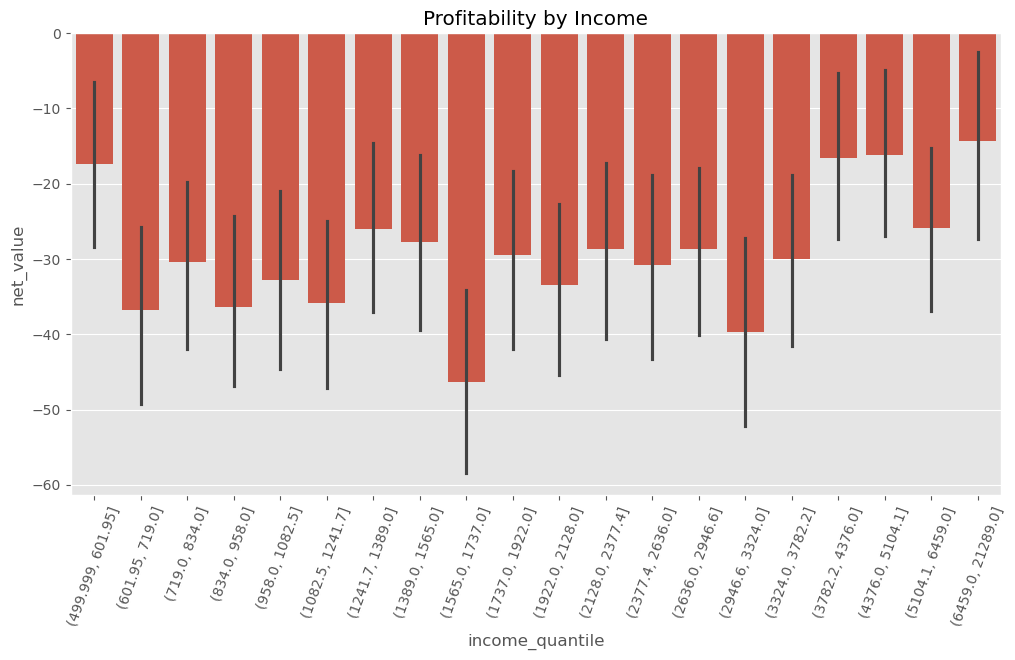

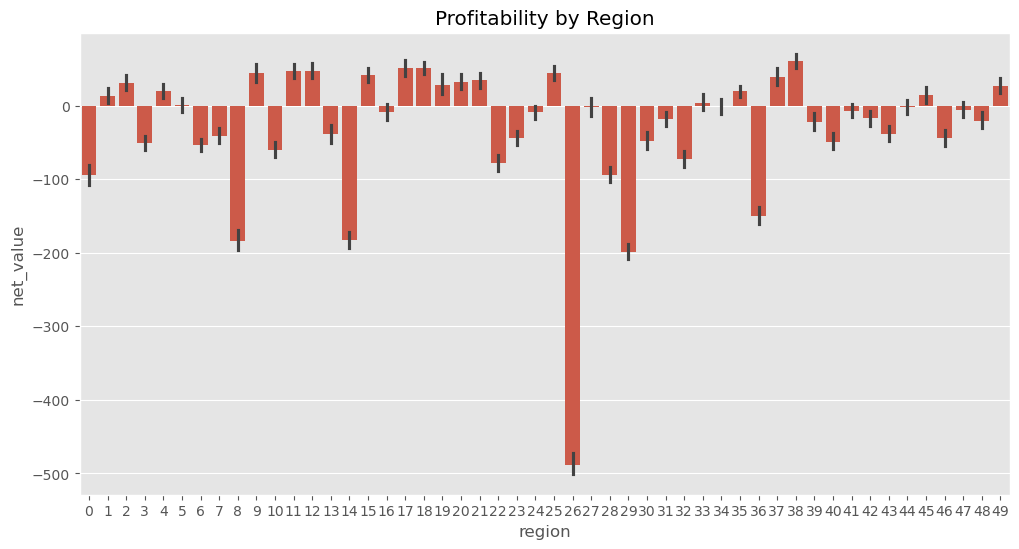

In [20]:
plt.figure(figsize=(12,6))
np.random.seed(123) ## seed because the CIs from seaborn uses boostrap

# pd.qcut create quantiles of a column
sns.barplot(data=train.assign(income_quantile=pd.qcut(train["income"], q=20)), 
            x="income_quantile", y="net_value")
plt.title("Profitability by Income")
plt.xticks(rotation=70);

plt.figure(figsize=(12,6))
np.random.seed(123)
region_plot = sns.barplot(data=train, x="region", y="net_value")
plt.title("Profitability by Region");

regions_to_net = train.groupby('region')['net_value'].agg(['mean', 'count', 'std'])

regions_to_net = regions_to_net.assign(
    lower_bound=regions_to_net['mean'] - 1.96*regions_to_net['std']/(regions_to_net['count']**0.5)
)

regions_to_net_lower_bound = regions_to_net['lower_bound'].to_dict()
regions_to_net = regions_to_net['mean'].to_dict()

# filters regions where the net value lower bound is > 0.
regions_to_invest = {region: net 
                     for region, net in regions_to_net_lower_bound.items()
                     if net > 0}

regions_to_invest

Train R2:  0.7108790300152951
Test R2:  0.6938513063048141


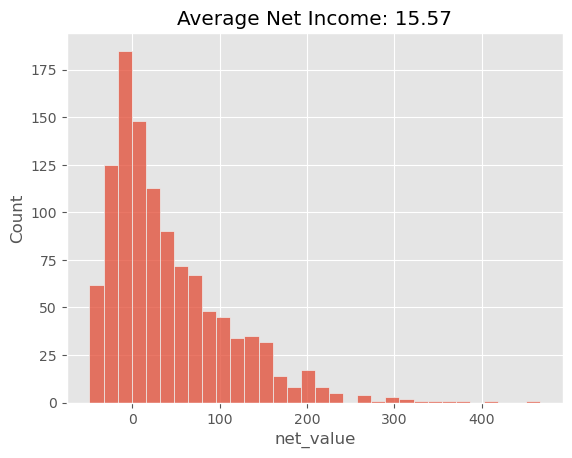

In [22]:
region_policy = (test[test["region"]
                      # filter regions in regions_to_invest
                      .isin(regions_to_invest.keys())]) 

sns.histplot(data=region_policy, x="net_value")
# average has to be over all customers, not just the one we've filtered with the policy
plt.title("Average Net Income: %.2f" % (region_policy["net_value"].sum() / test.shape[0]));

def encode(df): 
    return df.replace({"region": regions_to_net})

model_params = {'n_estimators': 400,
                'max_depth': 4,
                'min_samples_split': 10,
                'learning_rate': 0.01,
                'loss': 'squared_error'}

features = ["region", "income", "age"]
target = "net_value"

np.random.seed(123)

reg = ensemble.GradientBoostingRegressor(**model_params)

# fit model on the training set
encoded_train = train[features].pipe(encode)
reg.fit(encoded_train, train[target]);

train_pred = (encoded_train
              .assign(predictions=reg.predict(encoded_train[features])))

print("Train R2: ", r2_score(y_true=train[target], y_pred=train_pred["predictions"]))
print("Test R2: ", r2_score(y_true=test[target], y_pred=reg.predict(test[features].pipe(encode))))

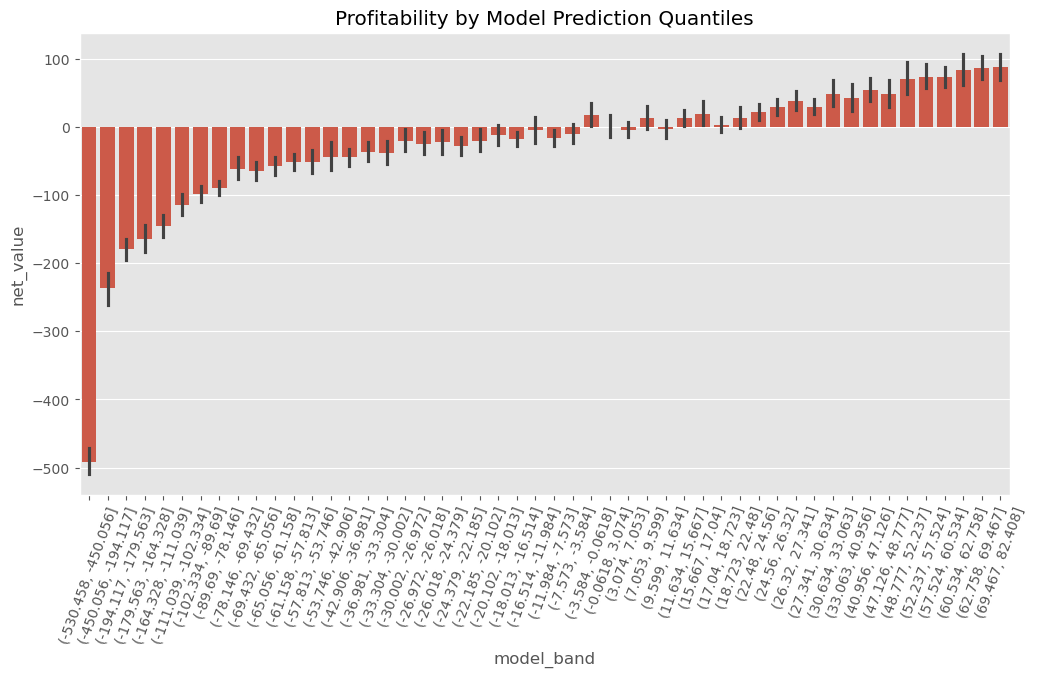

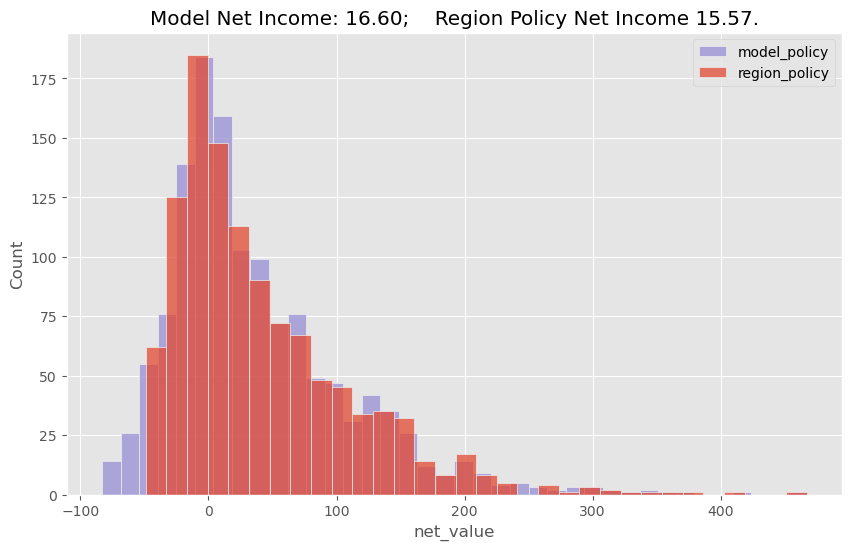

In [25]:
model_policy = test.assign(prediction=reg.predict(test[features].pipe(encode)))

model_policy.head()

plt.figure(figsize=(12,6))

n_bands = 50
bands = [f"band_{b}" for b in range(1,n_bands+1)]

np.random.seed(123)
model_plot = sns.barplot(data=model_policy
                         .assign(model_band = pd.qcut(model_policy["prediction"], q=n_bands)),
                         x="model_band", y="net_value")
plt.title("Profitability by Model Prediction Quantiles")
plt.xticks(rotation=70);

plt.figure(figsize=(10,6))
model_plot_df = (model_policy[model_policy["prediction"]>0])
sns.histplot(data=model_plot_df, x="net_value", color="C2", label="model_policy")

region_plot_df = (model_policy[model_policy["region"].isin(regions_to_invest.keys())])
sns.histplot(data=region_plot_df, x="net_value", label="region_policy")

plt.title("Model Net Income: %.2f;    Region Policy Net Income %.2f." % 
          (model_plot_df["net_value"].sum() / test.shape[0],
           region_plot_df["net_value"].sum() / test.shape[0]))
plt.legend();

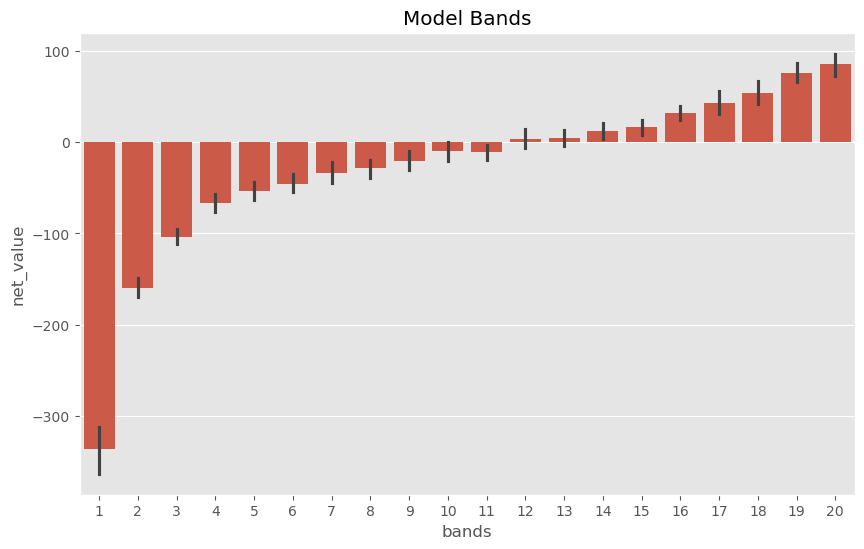

In [27]:
def model_binner(prediction_column, bins):
    # find the bins according to the training set
    bands = pd.qcut(prediction_column, q=bins, retbins=True)[1]
    
    def binner_function(prediction_column):
        return np.digitize(prediction_column, bands)
    
    return binner_function
    

# train the binning function
binner_fn = model_binner(train_pred["predictions"], 20)

# apply the binning
model_band = model_policy.assign(bands = binner_fn(model_policy["prediction"]))
model_band.head()

plt.figure(figsize=(10,6))
sns.barplot(data=model_band, x="bands", y="net_value")
plt.title("Model Bands");

## 18) Heterogeneous Treatment Effects and Personalization


There is both the data generating process and our intervention/treatment
$$E[Y|X,T]$$

So optimiziation $$\arg \max_T E[Y|X,T]$$

Conditional Average Treatment Effect (CATE)

$$E[Y_1 - Y_0|X] \text{ or } E[y'(t)|X]$$

Who do we treat (binary)? What is the right dosage (cont)? Conditional Treatment Effect $\frac{\delta Y}{\delta T}$. For instance, we want price sensitivity/elasticity $\frac{\delta Sales}{\delta Price}$ but can't see it. There is an individual sensitivity $\frac{\delta Y_i}{\delta T_i}$. To estimate, need different days with different prices and see difference in sales

$$ \frac{\delta Y_i}{\delta T_i} \approx \frac{Y(T_i) - Y(T_i + \varepsilon)}{T_i - (T_i + \varepsilon)} $$

but unobservable...

$$y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + e_i$$

$\frac{\delta y_i}{\delta t_i} = \beta_1$. Average Treatment Effect

$$y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + \beta_3 t_i X_i + e_i$$

$\hat{\frac{\delta y_i}{\delta t_i}} = \hat{\beta}_1 + \hat{\beta_3} X_i$ Conditional Average Treatment Effect CATE $E[y'(t)|X]$

In [4]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

# data
df = pd.read_csv("./data/ice_cream_sales_rnd.csv")

# split
np.random.seed(123)
train, test = train_test_split(df, test_size=0.25, random_state=123)

# 1) baseline model: same treatment effect for everyone
m1 = smf.ols(
    "sales ~ price + temp + C(weekday) + cost",
    data=train
).fit()

# 2) heterogeneous effect model: treatment effect varies with X
m2 = smf.ols(
    "sales ~ price*temp + price*C(weekday) + price*cost",
    data=train
).fit()

print(m1.summary().tables[1])
print(m2.summary().tables[1])


def pred_sensitivity(model, df, treatment="price", step=1.0):
    """
    Approximate the treatment derivative:
        dy/dt ≈ y_hat(t + step) - y_hat(t)

    For continuous treatments, this gives a model-based local sensitivity.
    """
    df_up = df.copy()
    df_up[treatment] = df_up[treatment] + step

    out = df.copy()
    out["pred_sens"] = (model.predict(df_up) - model.predict(df)) / step
    return out


# predicted treatment sensitivities on test set
sens_m1 = pred_sensitivity(m1, test, treatment="price", step=1.0)
sens_m2 = pred_sensitivity(m2, test, treatment="price", step=1.0)

# compare
print(sens_m1[["temp", "weekday", "cost", "price", "sales", "pred_sens"]].head())
print(sens_m2[["temp", "weekday", "cost", "price", "sales", "pred_sens"]].head())

# segment units into low/high sensitivity groups
sens_m2["sens_band"] = pd.qcut(sens_m2["pred_sens"], q=2, labels=["more_sensitive", "less_sensitive"])

# average observed relationship by band
summary = sens_m2.groupby("sens_band")[["pred_sens", "sales", "price"]].mean()
print(summary)

# if you want the implied closed-form CATE for this linear interaction model,
# it is the derivative of the regression equation w.r.t. price.
# statsmodels stores the estimated coefficients in model.params
print(m2.params)

                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         186.7113      1.770    105.499      0.000     183.241     190.181
C(weekday)[T.2]   -25.0512      0.924    -27.114      0.000     -26.863     -23.240
C(weekday)[T.3]   -24.5834      0.901    -27.282      0.000     -26.350     -22.817
C(weekday)[T.4]   -24.3807      0.897    -27.195      0.000     -26.138     -22.623
C(weekday)[T.5]   -24.9036      0.894    -27.850      0.000     -26.657     -23.150
C(weekday)[T.6]   -24.0921      0.903    -26.693      0.000     -25.862     -22.323
C(weekday)[T.7]    -0.8635      0.888     -0.972      0.331      -2.605       0.878
price              -2.7515      0.106    -25.970      0.000      -2.959      -2.544
temp                1.9848      0.060     33.117      0.000       1.867       2.102
cost                4.4718      0.528      8.462      0.000       3.436     

/var/folders/nd/lxb8r_lj6614y5lw1vkn3l100000gn/T/ipykernel_91483/3020606125.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = sens_m2.groupby("sens_band")[["pred_sens", "sales", "price"]].mean()


## 19. Evaluating Causal Models

ML has train-test validation. Can convince stakeholders it works. Causal Inference has beautiful theory but we estimate is invisible.

What ends up happening is that we often have an abundance of data where the treatment is NOT random and very few, if any, random data. Since evaluating a model with non random data is incredibly tricky, if we have any random data, we tend to leave that for evaluation purposes.

First model
$$sales_i = \beta_0 + \beta_1 price_i + \beta_2 X_i + \beta_3 X_i price_i + e_i $$


$$ \widehat{\frac{\delta sales}{\delta price}} = \hat{\beta}_1 + \hat{\beta_3}X_i $$

Second model: nonparametric ML predictive

$$ sales_i = G(X_i, price_i) + e_i$$

Our models were trained on non-random data. Now we turn to the random data to make predictions. Just so we have everything in one place, we will add the predictions from the machine learning model and the sensitivity prediction from the causal model in a single dataframe, prices_rnd_pred.

Moreover, let’s also include a random model. The idea is that this model just outputs random numbers as predictions. It is obviously not very useful, but it shall serve well as a benchmark. Whenever we are talking about new ways of making evaluations, I always like to think about how a random (useless) model would do. If the random model is able to perform well on the evaluation criterion, that says something about how good the evaluation method really is.


###

## 19) Evaluating Causal Models

This chapter is basically about a big annoying problem:

In prediction, evaluation is easy.
You predict \(Y\), then compare with the true \(Y\).

But in causal inference, what we want is something like

$$
\frac{\delta Y}{\delta T}
\quad \text{or} \quad
Y_1 - Y_0
$$

and we never directly observe that for each unit.

So then...
how do we know if a causal model is good?

---

The trick is:

even if we **cannot validate individual treatment effects**,
we can still check whether the model is good at **ordering people/days/units by treatment sensitivity**.

That is the real point.

A good causal model for personalization does not need to know the exact true effect for each unit.
It needs to help us separate units into things like:

- more sensitive
- less sensitive
- dangerous to treat
- safe to treat
- high gain
- low gain

If treatment in the evaluation sample is randomized, then inside a **group** we can estimate treatment sensitivity cleanly.

So the evaluation logic becomes:

1. use the model to score/rank units by predicted sensitivity
2. split them into bands/groups
3. inside each group, estimate the actual average sensitivity using randomized data
4. see whether the model really put high-sensitivity units together and low-sensitivity units together

That is the chapter’s main idea.

---

So instead of asking

> “did the model estimate each person’s true effect?”

we ask

> “did the model sort units in a useful causal order?”

That is much more realistic.

---

## Sensitivity by Band

First evaluation idea:

- sort by model score
- divide into quantile bands
- estimate sensitivity inside each band

For continuous treatment, sensitivity in a group is just the slope from regressing outcome on treatment:

$$
y_i = \beta_0 + \beta_1 t_i + e_i
$$

and the group sensitivity is

$$
\hat{\beta}_1
=
\frac{\sum (t_i-\bar t)(y_i-\bar y)}
{\sum (t_i-\bar t)^2}
$$

So if the model is useful, the bands should show **different** treatment sensitivities.

If all bands have basically the same sensitivity, the model is useless for personalization.

So:

- random model -> same sensitivity everywhere
- useful model -> clear separation between bands

This is already a pretty nice first check.

---

## Cumulative Sensitivity Curve

Band plots are nice, but a bit rough.

So the chapter improves this by creating a cumulative curve.

Idea:

- rank units by predicted sensitivity
- take the top \(k\)
- estimate sensitivity on those top \(k\)
- then top \(k+1\), top \(k+2\), and so on

This creates a sequence:

$$
\widehat{y'(t)}_k
$$

where each point tells us:

> “if I acted on the top \(k\) units according to this model, what treatment sensitivity would I get?”

This is cool because now we can judge whether the model is really putting the best units on top.

A good model should have:

- high sensitivity near the beginning
- then slowly move toward the global average as more units are included

A random model should just wobble around the average.

So the cumulative sensitivity curve tells us how good the ordering is.

---

## Cumulative Gain Curve

Then the chapter makes one more improvement.

Take cumulative sensitivity and multiply by the fraction of data included:

$$
\widehat{F(t)}_k
=
\hat{\beta}_{1,k}\frac{k}{N}
$$

Why?

Because now you balance:

- how strong the effect is
- how many units you are covering

This gives a much more useful comparison.

And the benchmark becomes a straight “random model” line from 0 to the overall average treatment effect.

So the interpretation becomes very intuitive:

- the farther the curve is from the random line, the better the model
- this is kind of like an ROC-style idea for causal ranking

This is probably the cleanest takeaway of the chapter.

---

## Confidence Intervals

Finally, since all of this is based on estimated slopes, we should include uncertainty.

For the simple linear regression slope, the standard error is:

$$
s_{\hat\beta_1}
=
\sqrt{
\frac{\sum \hat\epsilon_i^2}
{(n-2)\sum (t_i-\bar t)^2}
}
$$

Then we can build confidence intervals around the cumulative sensitivity or cumulative gain curves.

As sample size grows, the CI tends to shrink.

---

## Big picture

This chapter is really saying:

- causal models cannot usually be evaluated like predictive models
- we do not observe true individual treatment effects
- but we *can* evaluate whether a model is useful for **ranking and personalization**
- randomized data is incredibly valuable for that evaluation
- the best tools here are:
  - sensitivity by band
  - cumulative sensitivity curve
  - cumulative gain curve
  - confidence intervals

So the goal is not:

> “recover the exact hidden slope of every unit”

but rather:

> “build a model that orders units well enough to support better treatment decisions”


sensitivity_m_pred
          sensitivity_m_pred_band  band_sensitivity
0  (-18.778000000000002, -14.073]        -11.747487
1              (-14.073, -12.538]         -9.850546
2               (-12.538, -4.218]         -7.872637
3                (-4.218, -1.941]          2.157417
4                (-1.941, -1.103]          1.285341
5                (-1.103, -0.421]          0.506372
6                 (-0.421, 0.217]          0.312988
7                  (0.217, 0.898]         -0.289010
8                  (0.898, 1.693]         -0.666963
9                  (1.693, 5.565]         -1.958290

pred_m_pred
                pred_m_pred_band  band_sensitivity
0  (148.81799999999998, 176.777]          2.491128
1             (176.777, 182.693]          2.683296
2             (182.693, 187.432]          2.025007
3             (187.432, 191.527]          1.613456
4             (191.527, 195.526]          0.357217
5             (195.526, 199.225]          0.668942
6             (199.225, 204.214]      

/var/folders/nd/lxb8r_lj6614y5lw1vkn3l100000gn/T/ipykernel_91483/3514041941.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sensitivity(g, y, t))
/var/folders/nd/lxb8r_lj6614y5lw1vkn3l100000gn/T/ipykernel_91483/3514041941.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sensitivity(g, y, t))
/var/folders/nd/lxb8r_lj6614y5lw1vkn3l100000gn/T/ipykernel_91483/351404194

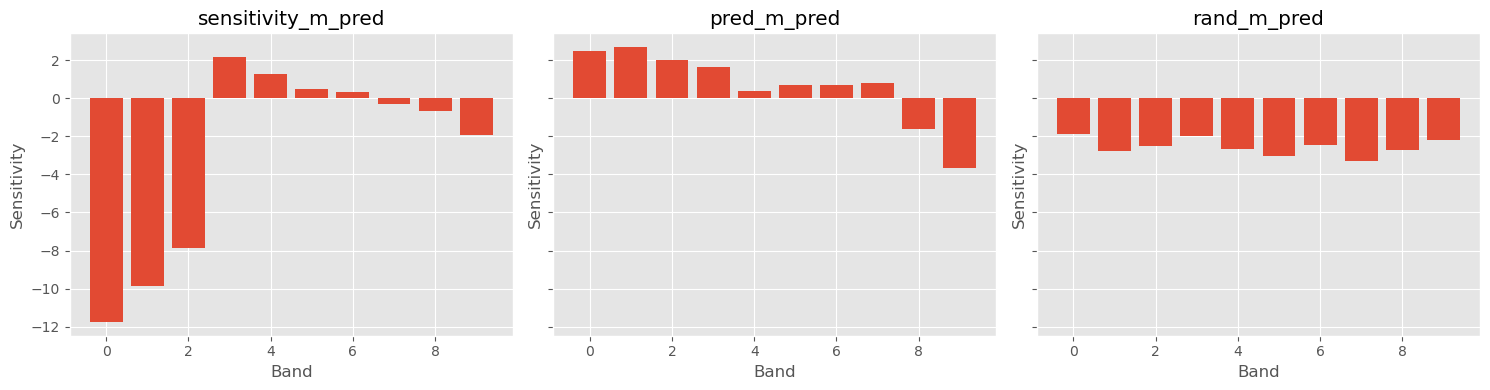

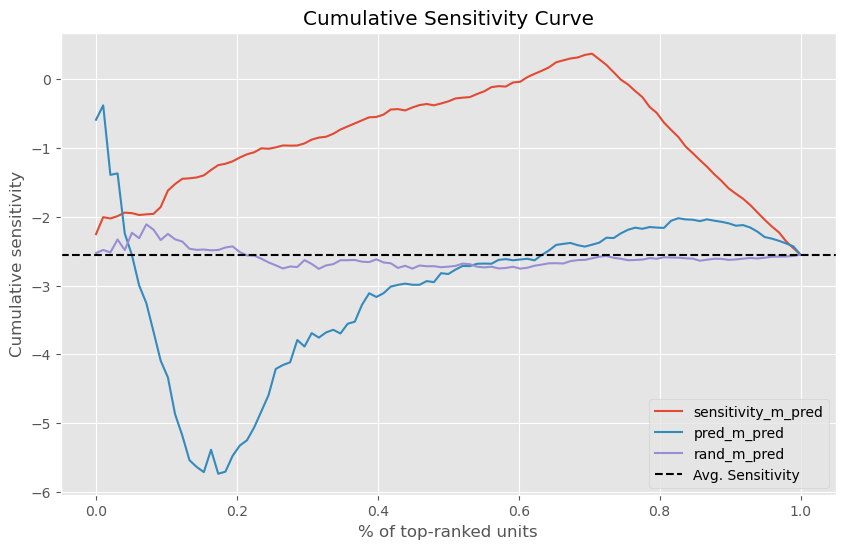

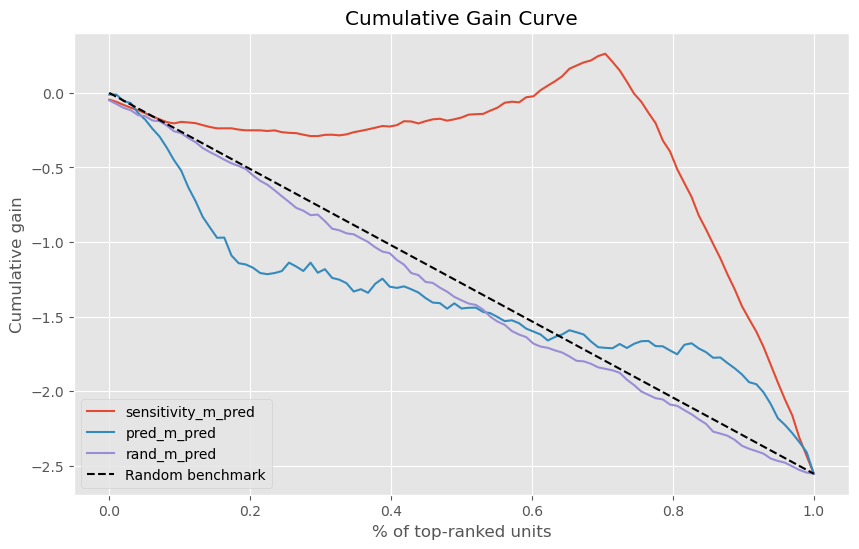

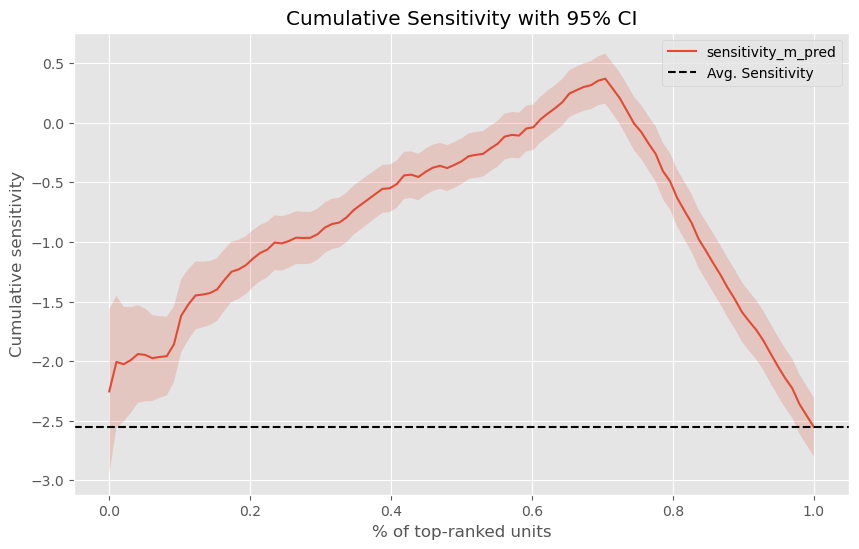

In [11]:
def predict_sensitivity(model, price_df, h=0.01):
    return (model.predict(price_df.assign(price=price_df["price"]+h))
            - model.predict(price_df)) / h

np.random.seed(123)
prices_rnd_pred = prices_rnd.assign(**{
    "sensitivity_m_pred": predict_sensitivity(m1, prices_rnd), ## sensitivity model
    "pred_m_pred": m2.predict(prices_rnd[X]), ## predictive model
    "rand_m_pred": np.random.uniform(size=prices_rnd.shape[0]), ## random model
})

prices_rnd_pred.head()


# --------------------------------------------------
# 1) Load data
# --------------------------------------------------
prices = pd.read_csv("./data/ice_cream_sales.csv")          # non-random training data
prices_rnd = pd.read_csv("./data/ice_cream_sales_rnd.csv")  # randomized evaluation data

X = ["temp", "weekday", "cost", "price"]
y = "sales"
t = "price"

# --------------------------------------------------
# 2) Train two models
# --------------------------------------------------
# causal-style linear model with interactions
m1 = smf.ols(
    "sales ~ price*cost + price*C(weekday) + price*temp",
    data=prices
).fit()

# predictive ML model
m2 = GradientBoostingRegressor(random_state=1)
m2.fit(prices[X], prices[y])

# --------------------------------------------------
# 3) Predict treatment sensitivity numerically
# --------------------------------------------------
def predict_sensitivity(model, df, treatment="price", h=0.01):
    df_up = df.copy()
    df_up[treatment] = df_up[treatment] + h
    return (model.predict(df_up) - model.predict(df)) / h

np.random.seed(123)
prices_rnd_pred = prices_rnd.assign(
    sensitivity_m_pred=predict_sensitivity(m1, prices_rnd, treatment="price", h=0.01),
    pred_m_pred=m2.predict(prices_rnd[X]),
    rand_m_pred=np.random.uniform(size=prices_rnd.shape[0])
)

# --------------------------------------------------
# 4) Estimate sensitivity inside any group
#    (simple regression slope of y on t)
# --------------------------------------------------
def sensitivity(df, y, t):
    num = ((df[t] - df[t].mean()) * (df[y] - df[y].mean())).sum()
    den = ((df[t] - df[t].mean()) ** 2).sum()
    return num / den

# --------------------------------------------------
# 5) Sensitivity by band
# --------------------------------------------------
def sensitivity_by_band(df, pred, y, t, bands=10):
    band_col = f"{pred}_band"
    out = (
        df.assign(**{band_col: pd.qcut(df[pred], q=bands, duplicates="drop")})
          .groupby(band_col, observed=False)
          .apply(lambda g: sensitivity(g, y, t))
          .reset_index(name="band_sensitivity")
    )
    return out

for m in ["sensitivity_m_pred", "pred_m_pred", "rand_m_pred"]:
    print(f"\n{m}")
    print(sensitivity_by_band(prices_rnd_pred, m, y, t, bands=10))

# simple plot
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, m in zip(axs, ["sensitivity_m_pred", "pred_m_pred", "rand_m_pred"]):
    tmp = sensitivity_by_band(prices_rnd_pred, m, y, t, bands=10)
    ax.bar(range(len(tmp)), tmp["band_sensitivity"])
    ax.set_title(m)
    ax.set_xlabel("Band")
    ax.set_ylabel("Sensitivity")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6) Cumulative sensitivity curve
# --------------------------------------------------
def cumulative_sensitivity_curve(dataset, prediction, y, t, min_periods=100, steps=100):
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    step_size = max(size // steps, 1)
    n_rows = list(range(min_periods, size, step_size)) + [size]
    return np.array([sensitivity(ordered_df.head(rows), y, t) for rows in n_rows])

plt.figure(figsize=(10, 6))

for m in ["sensitivity_m_pred", "pred_m_pred", "rand_m_pred"]:
    curve = cumulative_sensitivity_curve(prices_rnd_pred, m, y, t, min_periods=100, steps=100)
    x = np.arange(len(curve))
    plt.plot(x / x.max(), curve, label=m)

avg_sens = sensitivity(prices_rnd_pred, y, t)
plt.axhline(avg_sens, linestyle="--", color="black", label="Avg. Sensitivity")
plt.xlabel("% of top-ranked units")
plt.ylabel("Cumulative sensitivity")
plt.title("Cumulative Sensitivity Curve")
plt.legend()
plt.show()

# --------------------------------------------------
# 7) Cumulative gain curve
# --------------------------------------------------
def cumulative_gain(dataset, prediction, y, t, min_periods=100, steps=100):
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    step_size = max(size // steps, 1)
    n_rows = list(range(min_periods, size, step_size)) + [size]
    return np.array([
        sensitivity(ordered_df.head(rows), y, t) * (rows / size)
        for rows in n_rows
    ])

plt.figure(figsize=(10, 6))

for m in ["sensitivity_m_pred", "pred_m_pred", "rand_m_pred"]:
    gain = cumulative_gain(prices_rnd_pred, m, y, t, min_periods=100, steps=100)
    x = np.arange(len(gain))
    plt.plot(x / x.max(), gain, label=m)

plt.plot(
    [0, 1],
    [0, avg_sens],
    linestyle="--",
    color="black",
    label="Random benchmark"
)

plt.xlabel("% of top-ranked units")
plt.ylabel("Cumulative gain")
plt.title("Cumulative Gain Curve")
plt.legend()
plt.show()

# --------------------------------------------------
# 8) Confidence interval for sensitivity
# --------------------------------------------------
def sensitivity_ci(df, y, t, z=1.96):
    n = df.shape[0]
    t_bar = df[t].mean()
    beta1 = sensitivity(df, y, t)
    beta0 = df[y].mean() - beta1 * t_bar
    resid = df[y] - (beta0 + beta1 * df[t])

    se = np.sqrt((((resid ** 2).sum()) / (n - 2)) / (((df[t] - t_bar) ** 2).sum()))
    return np.array([beta1 - z * se, beta1 + z * se])

def cumulative_sensitivity_curve_ci(dataset, prediction, y, t, min_periods=100, steps=100):
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    step_size = max(size // steps, 1)
    n_rows = list(range(min_periods, size, step_size)) + [size]
    return np.array([sensitivity_ci(ordered_df.head(rows), y, t) for rows in n_rows])

# example: CI for the causal model
ci = cumulative_sensitivity_curve_ci(
    prices_rnd_pred,
    "sensitivity_m_pred",
    y,
    t,
    min_periods=100,
    steps=100
)

x = np.arange(len(ci))
mid = ci.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(x / x.max(), mid, label="sensitivity_m_pred")
plt.fill_between(x / x.max(), ci[:, 0], ci[:, 1], alpha=0.2)
plt.axhline(avg_sens, linestyle="--", color="black", label="Avg. Sensitivity")
plt.xlabel("% of top-ranked units")
plt.ylabel("Cumulative sensitivity")
plt.title("Cumulative Sensitivity with 95% CI")
plt.legend()
plt.show()